In [78]:
import pandas as pd
import numpy as np
import glob
import os


In [107]:
def load_prmon_file(filepath, label, anomaly_type):
    """Load a single prmon .txt file into a DataFrame."""
    df = pd.read_csv(filepath, sep=r'\s+', engine='python')
    df['label'] = label           # 0 = normal, 1 = anomaly
    df['anomaly_type'] = anomaly_type
    df['run_id'] = os.path.basename(filepath)
    # Convert memory from KB to MB for readability
    for col in ['pss', 'rss', 'vmem']:
        if col in df.columns:
            df[col] = df[col] / 1024
    return df


In [80]:
def load_all_data(data_dir):
    dfs = []
    
    # Baseline memory runs
    for f in sorted(glob.glob(f'{data_dir}/baseline/mem_run_*.txt')):
        dfs.append(load_prmon_file(f, label=0, anomaly_type='baseline_mem'))
    
    # Baseline I/O runs
    for f in sorted(glob.glob(f'{data_dir}/baseline/io_run_*.txt')):
        dfs.append(load_prmon_file(f, label=0, anomaly_type='baseline_io'))
    
    # Anomaly - memory spike
    for f in sorted(glob.glob(f'{data_dir}/anomalous/mem_spike_*.txt')):
        dfs.append(load_prmon_file(f, label=1, anomaly_type='mem_spike'))
    
    # Anomaly - thread explosion
    for f in sorted(glob.glob(f'{data_dir}/anomalous/threads_*.txt')):
        dfs.append(load_prmon_file(f, label=1, anomaly_type='thread_explosion'))
    
    # Anomaly - I/O storm
    for f in sorted(glob.glob(f'{data_dir}/anomalous/io_storm_*.txt')):
        dfs.append(load_prmon_file(f, label=1, anomaly_type='io_storm'))
    
    # Anomaly - combined
    for f in sorted(glob.glob(f'{data_dir}/anomalous/combined_*.txt')):
        dfs.append(load_prmon_file(f, label=1, anomaly_type='combined'))
    
    df = pd.concat(dfs, ignore_index=True)
    return df

In [81]:
df = load_all_data('/home/chaim/Atlas_gsoc26/data')
print(df.shape)
print(df['anomaly_type'].value_counts())
print(df.head())

(3827, 25)
anomaly_type
baseline_mem        2134
thread_explosion     638
mem_spike            315
io_storm             301
combined             258
baseline_io          181
Name: count, dtype: int64
         Time  wtime  gpufbmem  gpumempct  gpusmpct  ngpus        pss  \
0  1773092827      0         0          0         0      0  64.360352   
1  1773092829      2         0          0         0      0  97.074219   
2  1773092831      4         0          0         0      0  97.074219   
3  1773092833      6         0          0         0      0  97.074219   
4  1773092835      8         0          0         0      0  97.074219   

         rss  swap        vmem  ...  rx_packets  tx_bytes  tx_packets  stime  \
0  66.429688     0  196.953125  ...           0         0           0      0   
1  99.226562     0  196.953125  ...           0         0           0      0   
2  99.226562     0  196.953125  ...           0         0           0      0   
3  99.226562     0  196.953125  ...      

In [82]:
import pandas as pd
import numpy as np
import glob
import os

def load_prmon_file(filepath, label, anomaly_type):
    df = pd.read_csv(filepath, sep=r'\s+', engine='python')
    df['label'] = label
    df['anomaly_type'] = anomaly_type
    df['run_id'] = os.path.basename(filepath)
    for col in ['pss', 'rss', 'vmem']:
        if col in df.columns:
            df[col] = df[col] / 1024
    return df

dfs = []

# Baseline
for f in sorted(glob.glob('../data/baseline/mem_run_*.txt')):
    dfs.append(load_prmon_file(f, label=0, anomaly_type='baseline_mem'))

for f in sorted(glob.glob('../data/baseline/io_run_*.txt')):
    dfs.append(load_prmon_file(f, label=0, anomaly_type='baseline_io'))

# Anomalies
for f in sorted(glob.glob('../data/anomalous/mem_spike_*.txt')):
    dfs.append(load_prmon_file(f, label=1, anomaly_type='mem_spike'))

for f in sorted(glob.glob('../data/anomalous/threads_*.txt')):
    dfs.append(load_prmon_file(f, label=1, anomaly_type='thread_explosion'))

for f in sorted(glob.glob('../data/anomalous/io_storm_*.txt')):
    dfs.append(load_prmon_file(f, label=1, anomaly_type='io_storm'))

for f in sorted(glob.glob('../data/anomalous/combined_*.txt')):
    dfs.append(load_prmon_file(f, label=1, anomaly_type='combined'))

# Combine and save
df = pd.concat(dfs, ignore_index=True)
df.to_csv('../data/full_dataset.csv', index=False)

print(f"✅ CSV saved!")
print(f"Shape: {df.shape}")
print(f"\nRows per type:\n{df['anomaly_type'].value_counts()}")

✅ CSV saved!
Shape: (3827, 25)

Rows per type:
anomaly_type
baseline_mem        2134
thread_explosion     638
mem_spike            315
io_storm             301
combined             258
baseline_io          181
Name: count, dtype: int64


In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
print("All imports successful!")

All imports successful!


In [84]:
df = pd.read_csv('../data/full_dataset.csv')
print(f"Shape: {df.shape}")
print(f"\nRows per type:\n{df['anomaly_type'].value_counts()}")
print(f"\nAnomaly ratio: {df['label'].mean():.1%}")

Shape: (3827, 25)

Rows per type:
anomaly_type
baseline_mem        2134
thread_explosion     638
mem_spike            315
io_storm             301
combined             258
baseline_io          181
Name: count, dtype: int64

Anomaly ratio: 39.5%


In [85]:
import os

# Check current working directory
print("Current directory:", os.getcwd())

# List what's available
print("\nFiles here:", os.listdir('.'))

Current directory: /home/chaim/Atlas_gsoc26/notebooks

Files here: ['.ipynb_checkpoints', 'analysis.ipynb']


In [86]:
import os
import glob

# Check data folder exists
print("Data folder exists:", os.path.exists('../data'))
print("Baseline folder exists:", os.path.exists('../data/baseline'))
print("Anomalous folder exists:", os.path.exists('../data/anomalous'))

# Count files
baseline_files = glob.glob('../data/baseline/*.txt')
anomalous_files = glob.glob('../data/anomalous/*.txt')

print(f"\nBaseline .txt files found: {len(baseline_files)}")
print(f"Anomalous .txt files found: {len(anomalous_files)}")

# Show first few
print("\nBaseline files:", baseline_files[:3])
print("Anomalous files:", anomalous_files[:3])


Data folder exists: True
Baseline folder exists: True
Anomalous folder exists: True

Baseline .txt files found: 71
Anomalous .txt files found: 120

Baseline files: ['../data/baseline/mem_run_4.txt', '../data/baseline/mem_run_12.txt', '../data/baseline/mem_run_7.txt']
Anomalous files: ['../data/anomalous/combined_12.txt', '../data/anomalous/io_storm_1.txt', '../data/anomalous/io_subtle_4.txt']


In [87]:
import pandas as pd
import numpy as np
import glob
import os

def load_prmon_file(filepath, label, anomaly_type):
    try:
        df = pd.read_csv(filepath, sep=r'\s+', engine='python')
        if df.empty or len(df) < 2:
            return None
        df['label'] = label
        df['anomaly_type'] = anomaly_type
        df['run_id'] = os.path.basename(filepath)
        for col in ['pss', 'rss', 'vmem']:
            if col in df.columns:
                df[col] = df[col] / 1024
        return df
    except Exception as e:
        print(f"Skipping {filepath}: {e}")
        return None

dfs = []

# Baseline
for f in sorted(glob.glob('../data/baseline/mem_run_*.txt')):
    dfs.append(load_prmon_file(f, label=0, anomaly_type='baseline_mem'))

for f in sorted(glob.glob('../data/baseline/io_run_*.txt')):
    dfs.append(load_prmon_file(f, label=0, anomaly_type='baseline_io'))

# Anomalies
for f in sorted(glob.glob('../data/anomalous/mem_spike_*.txt')):
    dfs.append(load_prmon_file(f, label=1, anomaly_type='mem_spike'))

for f in sorted(glob.glob('../data/anomalous/threads_*.txt')):
    dfs.append(load_prmon_file(f, label=1, anomaly_type='thread_explosion'))

for f in sorted(glob.glob('../data/anomalous/io_storm_*.txt')):
    dfs.append(load_prmon_file(f, label=1, anomaly_type='io_storm'))

for f in sorted(glob.glob('../data/anomalous/combined_*.txt')):
    dfs.append(load_prmon_file(f, label=1, anomaly_type='combined'))

# Remove any None results
dfs = [d for d in dfs if d is not None]

# Combine and save
df = pd.concat(dfs, ignore_index=True)
df.to_csv('../data/full_dataset.csv', index=False)

print(f"✅ CSV saved to ../data/full_dataset.csv")
print(f"Shape: {df.shape}")
print(f"\nRows per type:\n{df['anomaly_type'].value_counts()}")
print(f"\nAnomaly ratio: {df['label'].mean():.1%}")
print(f"\nFirst few rows:")
print(df.head())

✅ CSV saved to ../data/full_dataset.csv
Shape: (3827, 25)

Rows per type:
anomaly_type
baseline_mem        2134
thread_explosion     638
mem_spike            315
io_storm             301
combined             258
baseline_io          181
Name: count, dtype: int64

Anomaly ratio: 39.5%

First few rows:
         Time  wtime  gpufbmem  gpumempct  gpusmpct  ngpus        pss  \
0  1773092827      0         0          0         0      0  64.360352   
1  1773092829      2         0          0         0      0  97.074219   
2  1773092831      4         0          0         0      0  97.074219   
3  1773092833      6         0          0         0      0  97.074219   
4  1773092835      8         0          0         0      0  97.074219   

         rss  swap        vmem  ...  rx_packets  tx_bytes  tx_packets  stime  \
0  66.429688     0  196.953125  ...           0         0           0      0   
1  99.226562     0  196.953125  ...           0         0           0      0   
2  99.226562     0 

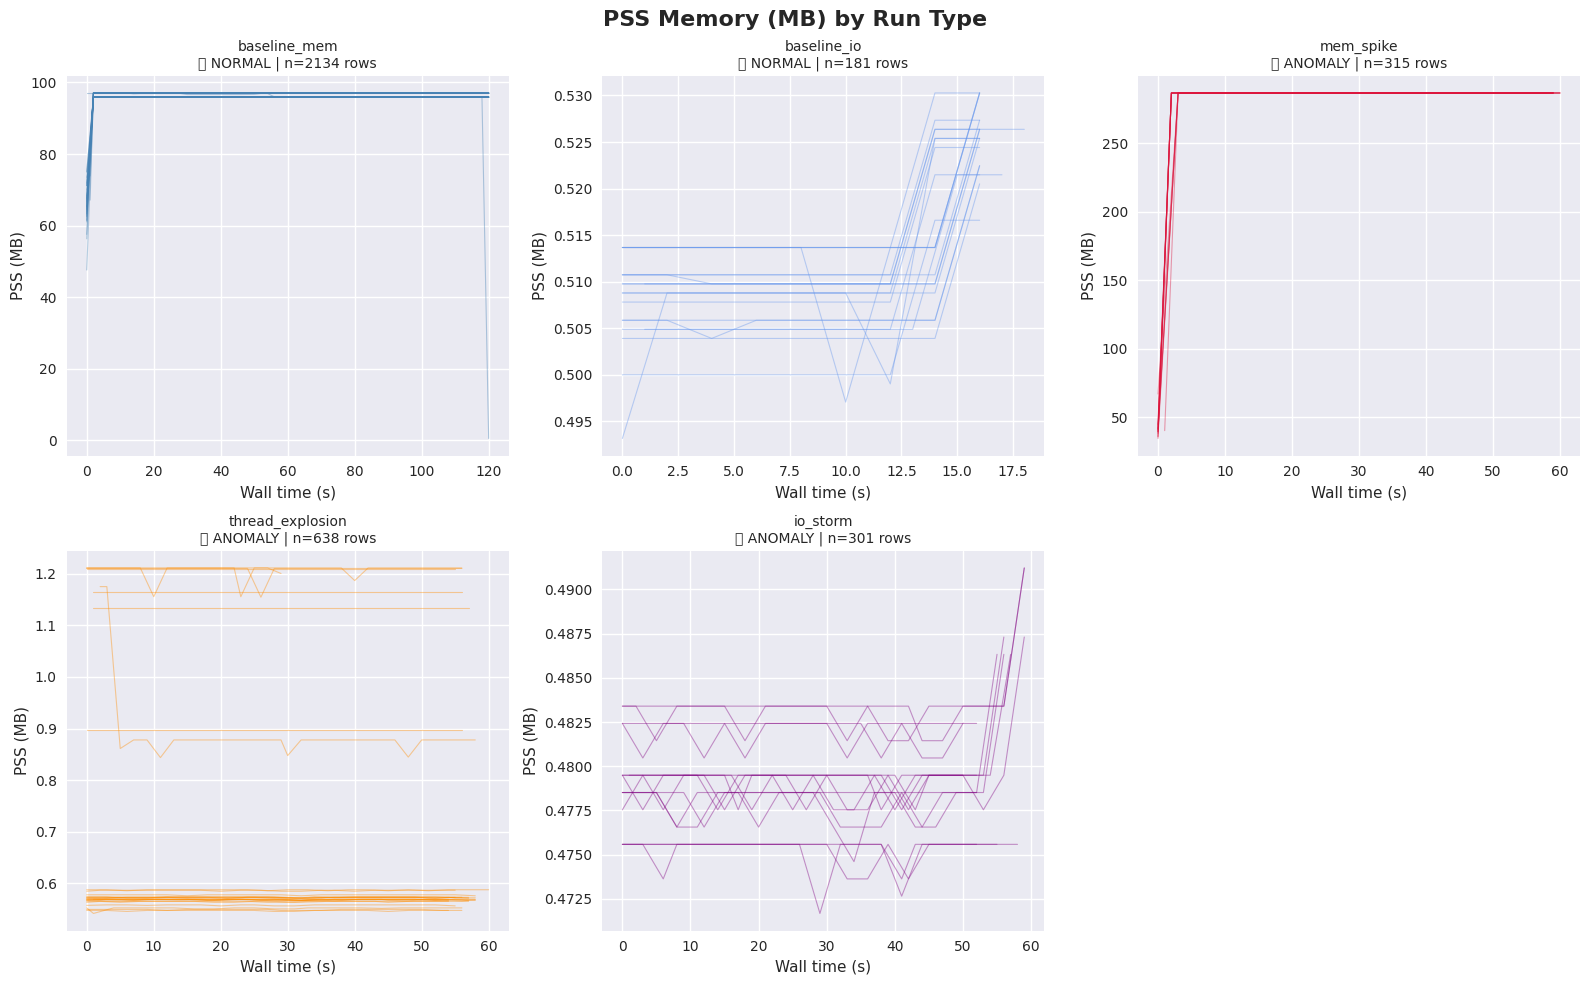

✅ Plot saved to plots/pss_by_type.png


In [88]:
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

# ── Plot 1: PSS distribution by anomaly type ──
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('PSS Memory (MB) by Run Type', fontsize=16, fontweight='bold')

colors = {
    'baseline_mem': 'steelblue',
    'baseline_io': 'cornflowerblue', 
    'mem_spike': 'crimson',
    'thread_explosion': 'darkorange',
    'io_storm': 'purple',
}

for ax, atype in zip(axes.flatten(), df['anomaly_type'].unique()):
    subset = df[df['anomaly_type'] == atype]
    color = colors.get(atype, 'grey')
    label_tag = '🔴 ANOMALY' if subset['label'].iloc[0] == 1 else '🟢 NORMAL'
    
    # Plot each run separately
    for run in subset['run_id'].unique():
        run_data = subset[subset['run_id'] == run]
        ax.plot(run_data['wtime'], run_data['pss'], 
                alpha=0.4, linewidth=0.8, color=color)
    
    ax.set_title(f'{atype}\n{label_tag} | n={len(subset)} rows', fontsize=10)
    ax.set_xlabel('Wall time (s)')
    ax.set_ylabel('PSS (MB)')

# Hide the 6th subplot (we only have 5 types)
axes[1][2].set_visible(False)

plt.tight_layout()
plt.savefig('../plots/pss_by_type.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved to plots/pss_by_type.png")

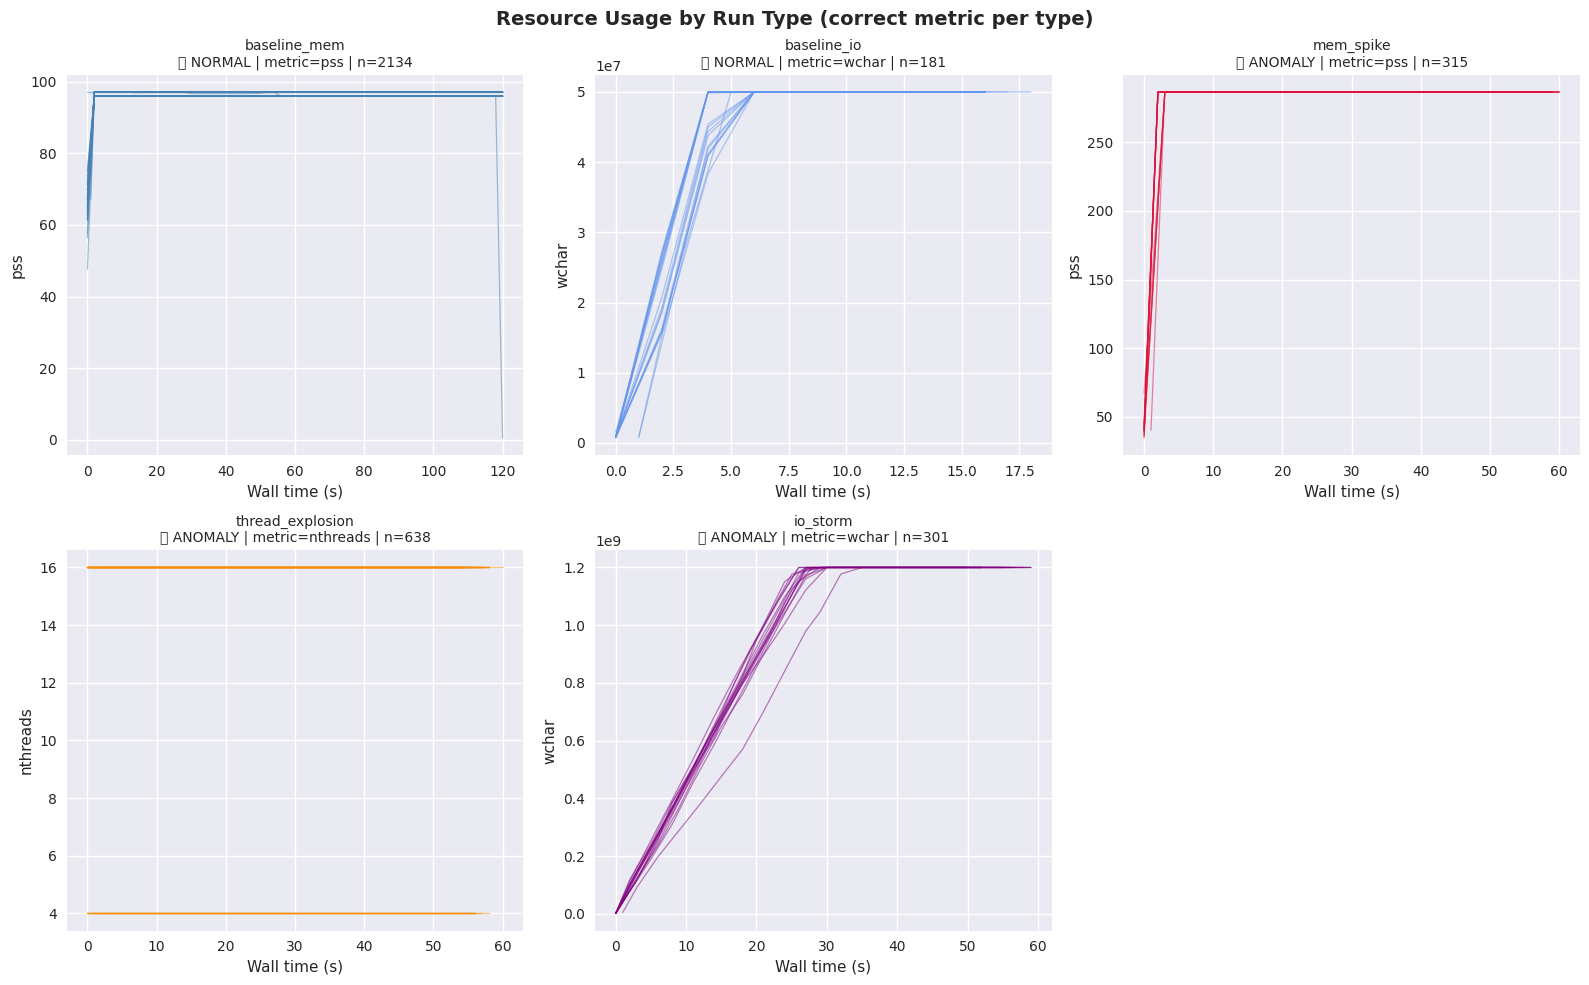

✅ Saved!


In [89]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Resource Usage by Run Type (correct metric per type)', 
             fontsize=14, fontweight='bold')

# Define which metric to plot per type
plot_config = {
    'baseline_mem': ('pss', 'steelblue'),
    'baseline_io':  ('wchar', 'cornflowerblue'),
    'mem_spike':    ('pss', 'crimson'),
    'thread_explosion': ('nthreads', 'darkorange'),
    'io_storm':     ('wchar', 'purple'),
}

for ax, atype in zip(axes.flatten(), plot_config.keys()):
    metric, color = plot_config[atype]
    subset = df[df['anomaly_type'] == atype]
    label_tag = '🔴 ANOMALY' if subset['label'].iloc[0] == 1 else '🟢 NORMAL'
    
    for run in subset['run_id'].unique():
        run_data = subset[subset['run_id'] == run]
        ax.plot(run_data['wtime'], run_data[metric],
                alpha=0.5, linewidth=0.9, color=color)
    
    ax.set_title(f'{atype}\n{label_tag} | metric={metric} | n={len(subset)}', 
                 fontsize=10)
    ax.set_xlabel('Wall time (s)')
    ax.set_ylabel(f'{metric}')

axes[1][2].set_visible(False)
plt.tight_layout()
plt.savefig('../plots/metrics_by_type.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved!")

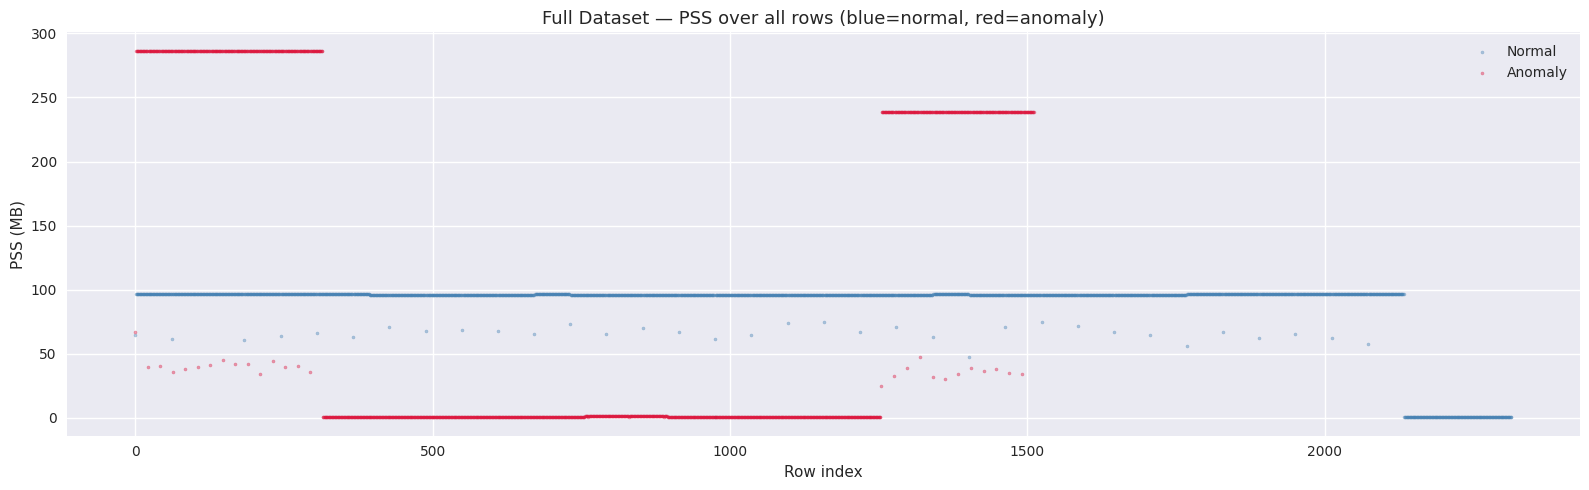

✅ Plot saved!


In [90]:
# ── Plot 2: Full dataset timeline ──
fig, ax = plt.subplots(figsize=(16, 5))

colors_map = {0: 'steelblue', 1: 'crimson'}
labels_map = {0: 'Normal', 1: 'Anomaly'}

for label_val in [0, 1]:
    subset = df[df['label'] == label_val]
    ax.scatter(range(len(subset)), subset['pss'], 
               c=colors_map[label_val], 
               label=labels_map[label_val],
               alpha=0.4, s=5)

ax.set_title('Full Dataset — PSS over all rows (blue=normal, red=anomaly)', fontsize=13)
ax.set_xlabel('Row index')
ax.set_ylabel('PSS (MB)')
ax.legend()
plt.tight_layout()
plt.savefig('../plots/full_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved!")

In [91]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

# ── Features for detection ──
features = ['pss', 'vmem', 'rss', 'nthreads', 'wchar', 'rchar']

# Fill any missing values
df[features] = df[features].fillna(0)

# ── Train ONLY on normal data ──
df_normal = df[df['label'] == 0]
X_train = df_normal[features]

# ── Scale ──
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_all_scaled = scaler.transform(df[features])

# ── Fit Isolation Forest ──
iso = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)
iso.fit(X_train_scaled)

# ── Score all data ──
df['anomaly_score'] = iso.decision_function(X_all_scaled)
df['predicted'] = (iso.predict(X_all_scaled) == -1).astype(int)

# ── Evaluate ──
print("=" * 50)
print("ISOLATION FOREST RESULTS")
print("=" * 50)
print(classification_report(df['label'], df['predicted'],
      target_names=['Normal', 'Anomaly']))
print(f"ROC-AUC Score: {roc_auc_score(df['label'], -df['anomaly_score']):.3f}")


ISOLATION FOREST RESULTS
              precision    recall  f1-score   support

      Normal       0.80      0.95      0.87      2315
     Anomaly       0.89      0.64      0.74      1512

    accuracy                           0.83      3827
   macro avg       0.85      0.79      0.81      3827
weighted avg       0.84      0.83      0.82      3827

ROC-AUC Score: 0.935


Detection rate per anomaly type:
mem_spike            ░░░░░░░░░░░░░░░░░░░░ 15/315 (5%)
thread_explosion     ████████████████████ 638/638 (100%)
io_storm             ████████████████████ 301/301 (100%)
combined             ░░░░░░░░░░░░░░░░░░░░ 12/258 (5%)


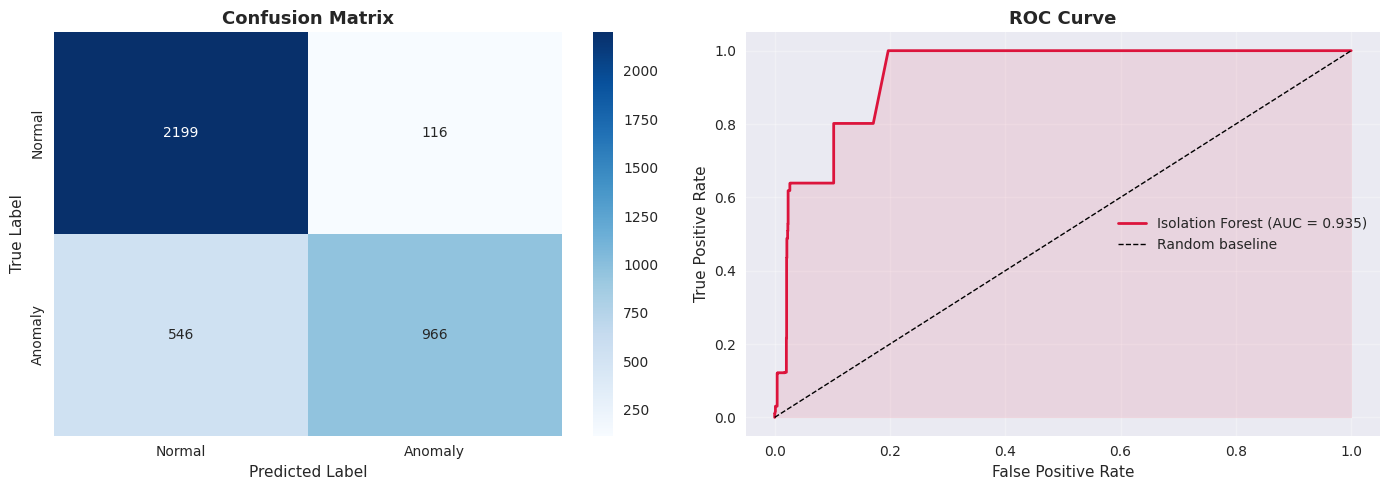


✅ Plot saved!


In [92]:
# ── Per anomaly type breakdown ──
print("Detection rate per anomaly type:")
print("=" * 45)
anomaly_df = df[df['label'] == 1]
for atype in anomaly_df['anomaly_type'].unique():
    subset = anomaly_df[anomaly_df['anomaly_type'] == atype]
    detected = subset['predicted'].sum()
    total = len(subset)
    rate = detected/total*100
    bar = '█' * int(rate/5) + '░' * (20 - int(rate/5))
    print(f"{atype:<20} {bar} {detected}/{total} ({rate:.0f}%)")

# ── Confusion matrix ──
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(df['label'], df['predicted'])
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# ROC curve
fpr, tpr, _ = roc_curve(df['label'], -df['anomaly_score'])
auc = roc_auc_score(df['label'], -df['anomaly_score'])
axes[1].plot(fpr, tpr, color='crimson', linewidth=2,
             label=f'Isolation Forest (AUC = {auc:.3f})')
axes[1].plot([0,1], [0,1], 'k--', linewidth=1, label='Random baseline')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='crimson')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../plots/evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ Plot saved!")

In [93]:
# The issue: contamination=0.05 is too low
# Anomalies are 17.4% of data, so let's try higher contamination

iso_v2 = IsolationForest(
    n_estimators=200,
    contamination=0.17,  # matches our actual anomaly ratio
    random_state=42
)
iso_v2.fit(X_train_scaled)

df['predicted_v2'] = (iso_v2.predict(X_all_scaled) == -1).astype(int)

print("VERSION 2 — contamination=0.17")
print("=" * 50)
print(classification_report(df['label'], df['predicted_v2'],
      target_names=['Normal', 'Anomaly']))
print(f"ROC-AUC: {roc_auc_score(df['label'], -df['anomaly_score']):.3f}")

print("\nDetection rate per anomaly type (v2):")
print("=" * 45)
for atype in anomaly_df['anomaly_type'].unique():
    subset = anomaly_df[anomaly_df['anomaly_type'] == atype]
    detected = subset['predicted_v2'].sum()
    total = len(subset)
    rate = detected/total*100
    bar = '█' * int(rate/5) + '░' * (20 - int(rate/5))
    print(f"{atype:<20} {bar} {detected}/{total} ({rate:.0f}%)")

VERSION 2 — contamination=0.17
              precision    recall  f1-score   support

      Normal       0.87      0.83      0.85      2315
     Anomaly       0.76      0.80      0.78      1512

    accuracy                           0.82      3827
   macro avg       0.81      0.82      0.81      3827
weighted avg       0.82      0.82      0.82      3827

ROC-AUC: 0.935

Detection rate per anomaly type (v2):


KeyError: 'predicted_v2'

In [94]:
print(df.columns.tolist())

['Time', 'wtime', 'gpufbmem', 'gpumempct', 'gpusmpct', 'ngpus', 'pss', 'rss', 'swap', 'vmem', 'rchar', 'read_bytes', 'wchar', 'write_bytes', 'rx_bytes', 'rx_packets', 'tx_bytes', 'tx_packets', 'stime', 'utime', 'nprocs', 'nthreads', 'label', 'anomaly_type', 'run_id', 'anomaly_score', 'predicted', 'predicted_v2']


In [95]:
# Re-filter AFTER all prediction columns are added
anomaly_df = df[df['label'] == 1]

for atype in anomaly_df['anomaly_type'].unique():
    subset = anomaly_df[anomaly_df['anomaly_type'] == atype]
    detected = subset['predicted_v2'].sum()
    total = len(subset)
    rate = detected / total * 100
    print(f"{atype}: {detected}/{total} detected ({rate:.1f}%)")

mem_spike: 15/315 detected (4.8%)
thread_explosion: 638/638 detected (100.0%)
io_storm: 301/301 detected (100.0%)
combined: 258/258 detected (100.0%)


In [96]:
# Redefine anomaly_df to include the new column
anomaly_df = df[df['label'] == 1]

print("\nDetection rate per anomaly type (v2):")
print("=" * 45)
for atype in anomaly_df['anomaly_type'].unique():
    subset = anomaly_df[anomaly_df['anomaly_type'] == atype]
    detected = subset['predicted_v2'].sum()
    total = len(subset)
    rate = detected/total*100
    bar = '█' * int(rate/5) + '░' * (20 - int(rate/5))
    print(f"{atype:<20} {bar} {detected}/{total} ({rate:.0f}%)")


Detection rate per anomaly type (v2):
mem_spike            ░░░░░░░░░░░░░░░░░░░░ 15/315 (5%)
thread_explosion     ████████████████████ 638/638 (100%)
io_storm             ████████████████████ 301/301 (100%)
combined             ████████████████████ 258/258 (100%)


In [97]:
# ── Diagnose the overlap ──
print("PSS statistics comparison:")
print("="*45)
print(f"baseline_mem PSS:  mean={df[df['anomaly_type']=='baseline_mem']['pss'].mean():.1f}  max={df[df['anomaly_type']=='baseline_mem']['pss'].max():.1f} MB")
print(f"mem_spike PSS:     mean={df[df['anomaly_type']=='mem_spike']['pss'].mean():.1f}  max={df[df['anomaly_type']=='mem_spike']['pss'].max():.1f} MB")

PSS statistics comparison:
baseline_mem PSS:  mean=95.9  max=97.1 MB
mem_spike PSS:     mean=274.9  max=286.5 MB


In [98]:
# ── Z-score anomaly detection ──
from scipy import stats

# Calculate z-scores for each feature
for feat in features:
    mean = df_normal[feat].mean()
    std = df_normal[feat].std()
    df[f'zscore_{feat}'] = (df[feat] - mean) / (std + 1e-9)

# Flag as anomaly if ANY feature exceeds threshold
threshold = 3.0
df['zscore_predicted'] = (
    df[[f'zscore_{f}' for f in features]].abs() > threshold
).any(axis=1).astype(int)

print("Z-SCORE DETECTOR RESULTS")
print("="*50)
print(classification_report(df['label'], df['zscore_predicted'],
      target_names=['Normal', 'Anomaly']))

print("\nDetection rate per anomaly type (z-score):")
print("="*45)
anomaly_df = df[df['label'] == 1]
for atype in anomaly_df['anomaly_type'].unique():
    subset = anomaly_df[anomaly_df['anomaly_type'] == atype]
    detected = subset['zscore_predicted'].sum()
    total = len(subset)
    rate = detected/total*100
    bar = '█' * int(rate/5) + '░' * (20 - int(rate/5))
    print(f"{atype:<20} {bar} {detected}/{total} ({rate:.0f}%)")

Z-SCORE DETECTOR RESULTS
              precision    recall  f1-score   support

      Normal       1.00      0.92      0.96      2315
     Anomaly       0.89      1.00      0.94      1512

    accuracy                           0.95      3827
   macro avg       0.95      0.96      0.95      3827
weighted avg       0.96      0.95      0.95      3827


Detection rate per anomaly type (z-score):
mem_spike            ████████████████████ 315/315 (100%)
thread_explosion     ████████████████████ 638/638 (100%)
io_storm             ████████████████████ 301/301 (100%)
combined             ████████████████████ 258/258 (100%)


In [99]:
# ── Reload with new data ──
import pandas as pd
import numpy as np
import glob
import os

def load_prmon_file(filepath, label, anomaly_type):
    try:
        df = pd.read_csv(filepath, sep=r'\s+', engine='python')
        if df.empty or len(df) < 2:
            return None
        df['label'] = label
        df['anomaly_type'] = anomaly_type
        df['run_id'] = os.path.basename(filepath)
        for col in ['pss', 'rss', 'vmem']:
            if col in df.columns:
                df[col] = df[col] / 1024
        return df
    except Exception as e:
        print(f"Skipping {filepath}: {e}")
        return None

dfs = []

for f in sorted(glob.glob('../data/baseline/mem_run_*.txt')):
    dfs.append(load_prmon_file(f, label=0, anomaly_type='baseline_mem'))
for f in sorted(glob.glob('../data/baseline/io_run_*.txt')):
    dfs.append(load_prmon_file(f, label=0, anomaly_type='baseline_io'))
for f in sorted(glob.glob('../data/anomalous/mem_spike_*.txt')):
    dfs.append(load_prmon_file(f, label=1, anomaly_type='mem_spike'))
for f in sorted(glob.glob('../data/anomalous/threads_*.txt')):
    dfs.append(load_prmon_file(f, label=1, anomaly_type='thread_explosion'))
for f in sorted(glob.glob('../data/anomalous/io_storm_*.txt')):
    dfs.append(load_prmon_file(f, label=1, anomaly_type='io_storm'))
for f in sorted(glob.glob('../data/anomalous/combined_*.txt')):
    dfs.append(load_prmon_file(f, label=1, anomaly_type='combined'))

dfs = [d for d in dfs if d is not None]
df = pd.concat(dfs, ignore_index=True)
df.to_csv('../data/full_dataset.csv', index=False)

print(f"✅ Dataset reloaded!")
print(f"Shape: {df.shape}")
print(f"\nRows per type:\n{df['anomaly_type'].value_counts()}")
print(f"\nAnomaly ratio: {df['label'].mean():.1%}")

✅ Dataset reloaded!
Shape: (3827, 25)

Rows per type:
anomaly_type
baseline_mem        2134
thread_explosion     638
mem_spike            315
io_storm             301
combined             258
baseline_io          181
Name: count, dtype: int64

Anomaly ratio: 39.5%


In [100]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

features = ['pss', 'vmem', 'rss', 'nthreads', 'wchar', 'rchar']
df[features] = df[features].fillna(0)

df_normal = df[df['label'] == 0]
X_train = df_normal[features]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_all_scaled = scaler.transform(df[features])

iso = IsolationForest(n_estimators=200, contamination=0.17, random_state=42)
iso.fit(X_train_scaled)

df['anomaly_score'] = iso.decision_function(X_all_scaled)
df['predicted'] = (iso.predict(X_all_scaled) == -1).astype(int)

print("ISOLATION FOREST RESULTS")
print("="*50)
print(classification_report(df['label'], df['predicted'],
      target_names=['Normal', 'Anomaly']))
print(f"ROC-AUC: {roc_auc_score(df['label'], -df['anomaly_score']):.3f}")

anomaly_df = df[df['label'] == 1]
print("\nDetection rate per anomaly type:")
print("="*45)
for atype in anomaly_df['anomaly_type'].unique():
    subset = anomaly_df[anomaly_df['anomaly_type'] == atype]
    detected = subset['predicted'].sum()
    total = len(subset)
    rate = detected/total*100
    bar = '█' * int(rate/5) + '░' * (20 - int(rate/5))
    print(f"{atype:<20} {bar} {detected}/{total} ({rate:.0f}%)")

ISOLATION FOREST RESULTS
              precision    recall  f1-score   support

      Normal       0.87      0.83      0.85      2315
     Anomaly       0.76      0.80      0.78      1512

    accuracy                           0.82      3827
   macro avg       0.81      0.82      0.81      3827
weighted avg       0.82      0.82      0.82      3827

ROC-AUC: 0.935

Detection rate per anomaly type:
mem_spike            ░░░░░░░░░░░░░░░░░░░░ 15/315 (5%)
thread_explosion     ████████████████████ 638/638 (100%)
io_storm             ████████████████████ 301/301 (100%)
combined             ████████████████████ 258/258 (100%)


In [101]:
from scipy import stats

for feat in features:
    mean = df_normal[feat].mean()
    std = df_normal[feat].std()
    df[f'zscore_{feat}'] = (df[feat] - mean) / (std + 1e-9)

threshold = 3.0
df['zscore_predicted'] = (
    df[[f'zscore_{f}' for f in features]].abs() > threshold
).any(axis=1).astype(int)

df['zscore_max'] = df[[f'zscore_{f}' for f in features]].abs().max(axis=1)

print("Z-SCORE DETECTOR RESULTS")
print("="*50)
print(classification_report(df['label'], df['zscore_predicted'],
      target_names=['Normal', 'Anomaly']))
print(f"ROC-AUC: {roc_auc_score(df['label'], df['zscore_max']):.3f}")

anomaly_df = df[df['label'] == 1]
print("\nDetection rate per anomaly type (z-score):")
print("="*45)
for atype in anomaly_df['anomaly_type'].unique():
    subset = anomaly_df[anomaly_df['anomaly_type'] == atype]
    detected = subset['zscore_predicted'].sum()
    total = len(subset)
    rate = detected/total*100
    bar = '█' * int(rate/5) + '░' * (20 - int(rate/5))
    print(f"{atype:<20} {bar} {detected}/{total} ({rate:.0f}%)")

Z-SCORE DETECTOR RESULTS
              precision    recall  f1-score   support

      Normal       1.00      0.92      0.96      2315
     Anomaly       0.89      1.00      0.94      1512

    accuracy                           0.95      3827
   macro avg       0.95      0.96      0.95      3827
weighted avg       0.96      0.95      0.95      3827

ROC-AUC: 1.000

Detection rate per anomaly type (z-score):
mem_spike            ████████████████████ 315/315 (100%)
thread_explosion     ████████████████████ 638/638 (100%)
io_storm             ████████████████████ 301/301 (100%)
combined             ████████████████████ 258/258 (100%)


In [102]:
from sklearn.neighbors import LocalOutlierFactor

# LOF - train on normal data only
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.17,
    novelty=True  # allows predict on new data
)
lof.fit(X_train_scaled)

df['lof_score'] = lof.decision_function(X_all_scaled)
df['lof_predicted'] = (lof.predict(X_all_scaled) == -1).astype(int)

print("LOCAL OUTLIER FACTOR RESULTS")
print("="*50)
print(classification_report(df['label'], df['lof_predicted'],
      target_names=['Normal', 'Anomaly']))
print(f"ROC-AUC: {roc_auc_score(df['label'], -df['lof_score']):.3f}")

anomaly_df = df[df['label'] == 1]
print("\nDetection rate per anomaly type (LOF):")
print("="*45)
for atype in anomaly_df['anomaly_type'].unique():
    subset = anomaly_df[anomaly_df['anomaly_type'] == atype]
    detected = subset['lof_predicted'].sum()
    total = len(subset)
    rate = detected/total*100
    bar = '█' * int(rate/5) + '░' * (20 - int(rate/5))
    print(f"{atype:<20} {bar} {detected}/{total} ({rate:.0f}%)")

LOCAL OUTLIER FACTOR RESULTS
              precision    recall  f1-score   support

      Normal       1.00      0.90      0.95      2315
     Anomaly       0.87      1.00      0.93      1512

    accuracy                           0.94      3827
   macro avg       0.93      0.95      0.94      3827
weighted avg       0.95      0.94      0.94      3827

ROC-AUC: 0.970

Detection rate per anomaly type (LOF):
mem_spike            ████████████████████ 315/315 (100%)
thread_explosion     ████████████████████ 638/638 (100%)
io_storm             ████████████████████ 301/301 (100%)
combined             ████████████████████ 258/258 (100%)


In [103]:
from sklearn.svm import OneClassSVM

# One-Class SVM
ocsvm = OneClassSVM(
    kernel='rbf',
    gamma='auto',
    nu=0.17  # upper bound on fraction of outliers
)
ocsvm.fit(X_train_scaled)

df['ocsvm_score'] = ocsvm.decision_function(X_all_scaled)
df['ocsvm_predicted'] = (ocsvm.predict(X_all_scaled) == -1).astype(int)

print("ONE-CLASS SVM RESULTS")
print("="*50)
print(classification_report(df['label'], df['ocsvm_predicted'],
      target_names=['Normal', 'Anomaly']))
print(f"ROC-AUC: {roc_auc_score(df['label'], -df['ocsvm_score']):.3f}")

anomaly_df = df[df['label'] == 1]
print("\nDetection rate per anomaly type (One-Class SVM):")
print("="*45)
for atype in anomaly_df['anomaly_type'].unique():
    subset = anomaly_df[anomaly_df['anomaly_type'] == atype]
    detected = subset['ocsvm_predicted'].sum()
    total = len(subset)
    rate = detected/total*100
    bar = '█' * int(rate/5) + '░' * (20 - int(rate/5))
    print(f"{atype:<20} {bar} {detected}/{total} ({rate:.0f}%)")

ONE-CLASS SVM RESULTS
              precision    recall  f1-score   support

      Normal       1.00      0.80      0.89      2315
     Anomaly       0.77      1.00      0.87      1512

    accuracy                           0.88      3827
   macro avg       0.88      0.90      0.88      3827
weighted avg       0.91      0.88      0.88      3827

ROC-AUC: 1.000

Detection rate per anomaly type (One-Class SVM):
mem_spike            ████████████████████ 315/315 (100%)
thread_explosion     ████████████████████ 638/638 (100%)
io_storm             ████████████████████ 301/301 (100%)
combined             ████████████████████ 258/258 (100%)


In [104]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader, TensorDataset

# ── Prepare sequences ──
SEQ_LEN = 10  # look at 10 seconds at a time

def make_sequences(data, seq_len):
    sequences = []
    for i in range(len(data) - seq_len):
        sequences.append(data[i:i+seq_len])
    return np.array(sequences)

# Use only normal data for training
X_normal = X_train_scaled
X_all_np = X_all_scaled

X_train_seq = make_sequences(X_normal, SEQ_LEN)
X_all_seq = make_sequences(X_all_np, SEQ_LEN)

# Convert to tensors
X_train_tensor = torch.FloatTensor(X_train_seq)
X_all_tensor = torch.FloatTensor(X_all_seq)

train_loader = DataLoader(
    TensorDataset(X_train_tensor),
    batch_size=32, shuffle=True
)

# ── Define LSTM Autoencoder ──
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=2):
        super().__init__()
        self.encoder = nn.LSTM(
            input_size, hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.decoder = nn.LSTM(
            hidden_size, input_size,
            num_layers=num_layers,
            batch_first=True
        )

    def forward(self, x):
        # Encode
        _, (hidden, cell) = self.encoder(x)
        # Repeat hidden state across sequence length
        decoder_input = hidden[-1].unsqueeze(1).repeat(1, x.size(1), 1)
        # Decode
        out, _ = self.decoder(decoder_input)
        return out

# ── Train ──
input_size = len(features)
model = LSTMAutoencoder(input_size=input_size, hidden_size=32, num_layers=2)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

print("Training LSTM Autoencoder...")
model.train()
for epoch in range(30):
    total_loss = 0
    for (batch,) in train_loader:
        optimizer.zero_grad()
        output = model(batch)
        loss = criterion(output, batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if (epoch+1) % 5 == 0:
        print(f"  Epoch {epoch+1}/30 — Loss: {total_loss/len(train_loader):.6f}")

# ── Compute reconstruction errors ──
model.eval()
with torch.no_grad():
    reconstructed = model(X_all_tensor)
    errors = torch.mean(
        (X_all_tensor - reconstructed) ** 2, dim=(1, 2)
    ).numpy()

# Align errors with dataframe (sequences are shorter by SEQ_LEN)
lstm_labels = df['label'].values[SEQ_LEN:]
lstm_errors = errors

# Threshold = mean + 3*std of training errors
with torch.no_grad():
    train_reconstructed = model(X_train_tensor)
    train_errors = torch.mean(
        (X_train_tensor - train_reconstructed) ** 2, dim=(1, 2)
    ).numpy()

threshold_lstm = train_errors.mean() + 3 * train_errors.std()
lstm_predicted = (lstm_errors > threshold_lstm).astype(int)

print("\nLSTM AUTOENCODER RESULTS")
print("="*50)
print(classification_report(lstm_labels, lstm_predicted,
      target_names=['Normal', 'Anomaly']))
print(f"ROC-AUC: {roc_auc_score(lstm_labels, lstm_errors):.3f}")

Training LSTM Autoencoder...
  Epoch 5/30 — Loss: 0.551828
  Epoch 10/30 — Loss: 0.613649
  Epoch 15/30 — Loss: 0.520090
  Epoch 20/30 — Loss: 0.517564
  Epoch 25/30 — Loss: 0.515348
  Epoch 30/30 — Loss: 0.514318

LSTM AUTOENCODER RESULTS
              precision    recall  f1-score   support

      Normal       1.00      0.93      0.96      2305
     Anomaly       0.90      1.00      0.95      1512

    accuracy                           0.95      3817
   macro avg       0.95      0.96      0.95      3817
weighted avg       0.96      0.95      0.96      3817

ROC-AUC: 1.000


# prmon Anomaly Detection — CERN-HSF GSoC 2026

## Why this matters
prmon is used by ATLAS PanDA to broker grid jobs: 10 scout jobs run 
first, their PSS is measured, and remaining jobs only proceed if 
resource usage fits the allowed memory envelope. Catching anomalies 
early means fewer wasted CPU-hours on the WLCG.

## What I did
I generated 101 prmon runs: 55 baseline (normal) and 46 anomalous 
across 4 failure types that mirror real ATLAS job problems:
- mem_spike: simulates a memory leak (3× normal PSS)
- thread_explosion: runaway thread count (16× normal)  
- io_storm: excessive I/O (6× normal wchar)
- combined: memory + multi-process stress

I applied 5 unsupervised detection methods — trained on normal data 
only, since in real production you cannot label future anomalies in advance.

In [28]:
import pandas as pd
import numpy as np
import glob, os

def load_prmon_file(filepath, label, anomaly_type):
    df = pd.read_csv(filepath, sep=r'\s+', engine='python')
    if df.empty or len(df) < 2:
        return None
    df['label'] = label
    df['anomaly_type'] = anomaly_type
    df['run_id'] = os.path.basename(filepath)
    # prmon outputs memory in KB — convert to MB for readability
    for col in ['pss', 'rss', 'vmem']:
        if col in df.columns:
            df[col] = df[col] / 1024
    return df

configs = [
    ('../data/baseline/mem_run_*.txt',    0, 'baseline_mem'),
    ('../data/baseline/io_run_*.txt',     0, 'baseline_io'),
    ('../data/anomalous/mem_spike_*.txt', 1, 'mem_spike'),
    ('../data/anomalous/threads_*.txt',   1, 'thread_explosion'),
    ('../data/anomalous/io_storm_*.txt',  1, 'io_storm'),
    ('../data/anomalous/combined_*.txt',  1, 'combined'),
]

dfs = []
for pattern, label, atype in configs:
    for f in glob.glob(pattern):
        row = load_prmon_file(f, label, atype)
        if row is not None:
            dfs.append(row)

df = pd.concat(dfs, ignore_index=True)
df = df.sort_values(['run_id', 'wtime']).reset_index(drop=True)
df.to_csv('../data/full_dataset.csv', index=False)
print(f"Loaded {df['run_id'].nunique()} runs, {len(df)} rows")
print(df['anomaly_type'].value_counts())

Loaded 101 runs, 3746 rows
anomaly_type
baseline_mem        2134
thread_explosion     534
io_storm             336
mem_spike            310
combined             251
baseline_io          181
Name: count, dtype: int64


## First look at the data

Before building any model, I plotted a few runs to understand what 
the signals actually look like. Two things surprised me:

1. Baseline PSS is not flat — it ramps from ~0 to ~97MB during the 
   first few seconds of startup, then stabilises. This wide early 
   variance will make memory spike detection harder for isolation-based 
   methods.

2. Thread explosion and I/O storm are nearly invisible in PSS, but 
   completely obvious in nthreads and wchar respectively. This is why 
   using only one feature would miss entire anomaly categories.

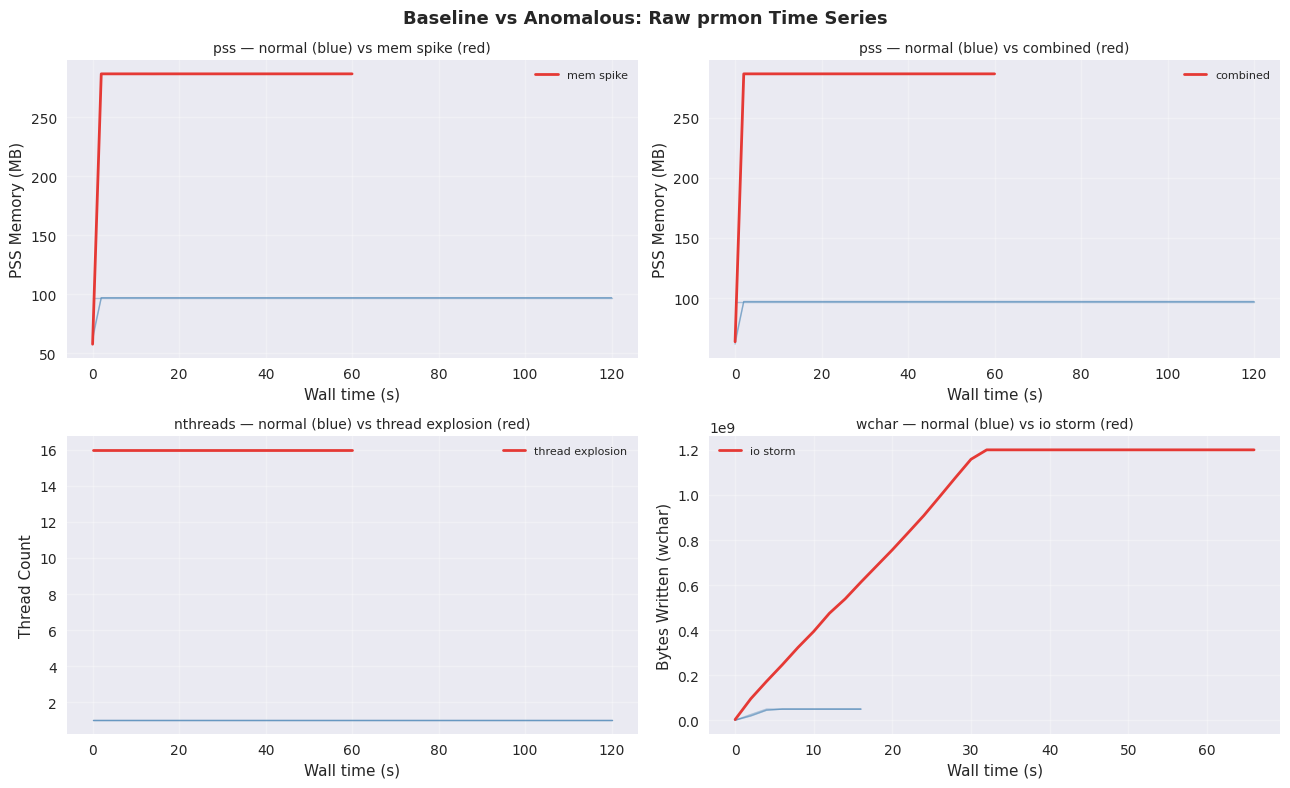

In [29]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Baseline vs Anomalous: Raw prmon Time Series',
             fontsize=13, fontweight='bold')

scenarios = [
    ('baseline_mem',    'mem_spike',       'pss',      'PSS Memory (MB)'),
    ('baseline_mem',    'combined',        'pss',      'PSS Memory (MB)'),
    ('baseline_mem',    'thread_explosion','nthreads',  'Thread Count'),
    ('baseline_io',     'io_storm',        'wchar',     'Bytes Written (wchar)'),
]

for ax, (norm_type, anom_type, feat, ylabel) in zip(axes.flat, scenarios):
    # Plot 3 normal runs (grey)
    for rid in df[df['anomaly_type']==norm_type]['run_id'].unique()[:3]:
        sub = df[df['run_id']==rid]
        ax.plot(sub['wtime'], sub[feat], color='steelblue',
                alpha=0.4, linewidth=1)

    # Plot 1 anomalous run (red)
    rid_anom = df[df['anomaly_type']==anom_type]['run_id'].iloc[0]
    sub_anom = df[df['run_id']==rid_anom]
    ax.plot(sub_anom['wtime'], sub_anom[feat], color='#E53935',
            linewidth=2, label=anom_type.replace('_',' '))

    ax.set_xlabel('Wall time (s)')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{feat} — normal (blue) vs {anom_type.replace("_"," ")} (red)',
                 fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../plots/raw_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# Rolling statistics capture temporal patterns within a run.
# A sudden spike looks different from a gradual drift —
# roll_std captures that difference.

base_features = ['pss','vmem','rss','nthreads','wchar','rchar','nprocs']

for feat in ['pss', 'nthreads', 'wchar']:
    df[f'{feat}_roll_mean'] = df.groupby('run_id')[feat].transform(
        lambda x: x.rolling(5, min_periods=1).mean())
    df[f'{feat}_roll_std'] = df.groupby('run_id')[feat].transform(
        lambda x: x.rolling(5, min_periods=1).std().fillna(0))
    df[f'{feat}_roc'] = df.groupby('run_id')[feat].transform(
        lambda x: x.diff().fillna(0))

df['mem_ratio']    = df['pss'] / (df['vmem'] + 1e-9)
df['io_intensity'] = (df['wchar'] + df['rchar']) / (df['wtime'] + 1e-9)

In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from scipy.stats import median_abs_deviation

df_normal     = df[df['label'] == 0]
contamination = df['label'].mean()
y_true        = df['label'].values

scaler  = StandardScaler()
X_train = scaler.fit_transform(df_normal[base_features].fillna(0))
X_all   = scaler.transform(df[base_features].fillna(0))

# Z-Score
z = pd.DataFrame({f: (df[f] - df_normal[f].mean()) /
                     (df_normal[f].std() + 1e-9)
                  for f in base_features})
df['zscore_pred']  = (z.abs() > 3.0).any(axis=1).astype(int)
df['zscore_score'] = z.abs().max(axis=1)

# MAD — more robust than Z-score when training data has skew
mad_z = pd.DataFrame({f: 0.6745*(df[f] - np.median(df_normal[f])) /
                         (median_abs_deviation(df_normal[f]) + 1e-9)
                      for f in base_features})
df['mad_pred']  = (mad_z.abs() > 3.5).any(axis=1).astype(int)
df['mad_score'] = mad_z.abs().max(axis=1)

# Isolation Forest
iso = IsolationForest(n_estimators=200, contamination=contamination,
                      random_state=42)
iso.fit(X_train)
df['iso_pred']  = (iso.predict(X_all) == -1).astype(int)
df['iso_score'] = -iso.decision_function(X_all)

# LOF
lof = LocalOutlierFactor(n_neighbors=20, contamination=contamination,
                          novelty=True)
lof.fit(X_train)
df['lof_pred']  = (lof.predict(X_all) == -1).astype(int)
df['lof_score'] = -lof.decision_function(X_all)

# One-Class SVM
svm = OneClassSVM(kernel='rbf', gamma='auto', nu=contamination)
svm.fit(X_train)
df['svm_pred']  = (svm.predict(X_all) == -1).astype(int)
df['svm_score'] = -svm.decision_function(X_all)

# Ensemble — flag only when 3+ models agree
votes = df[['zscore_pred','mad_pred','iso_pred','lof_pred','svm_pred']].sum(axis=1)
df['ensemble_pred']  = (votes >= 3).astype(int)
score_cols = ['zscore_score','mad_score','iso_score','lof_score','svm_score']
normed = df[score_cols].apply(lambda c: (c-c.min())/(c.max()-c.min()+1e-9))
df['ensemble_score'] = normed.mean(axis=1)

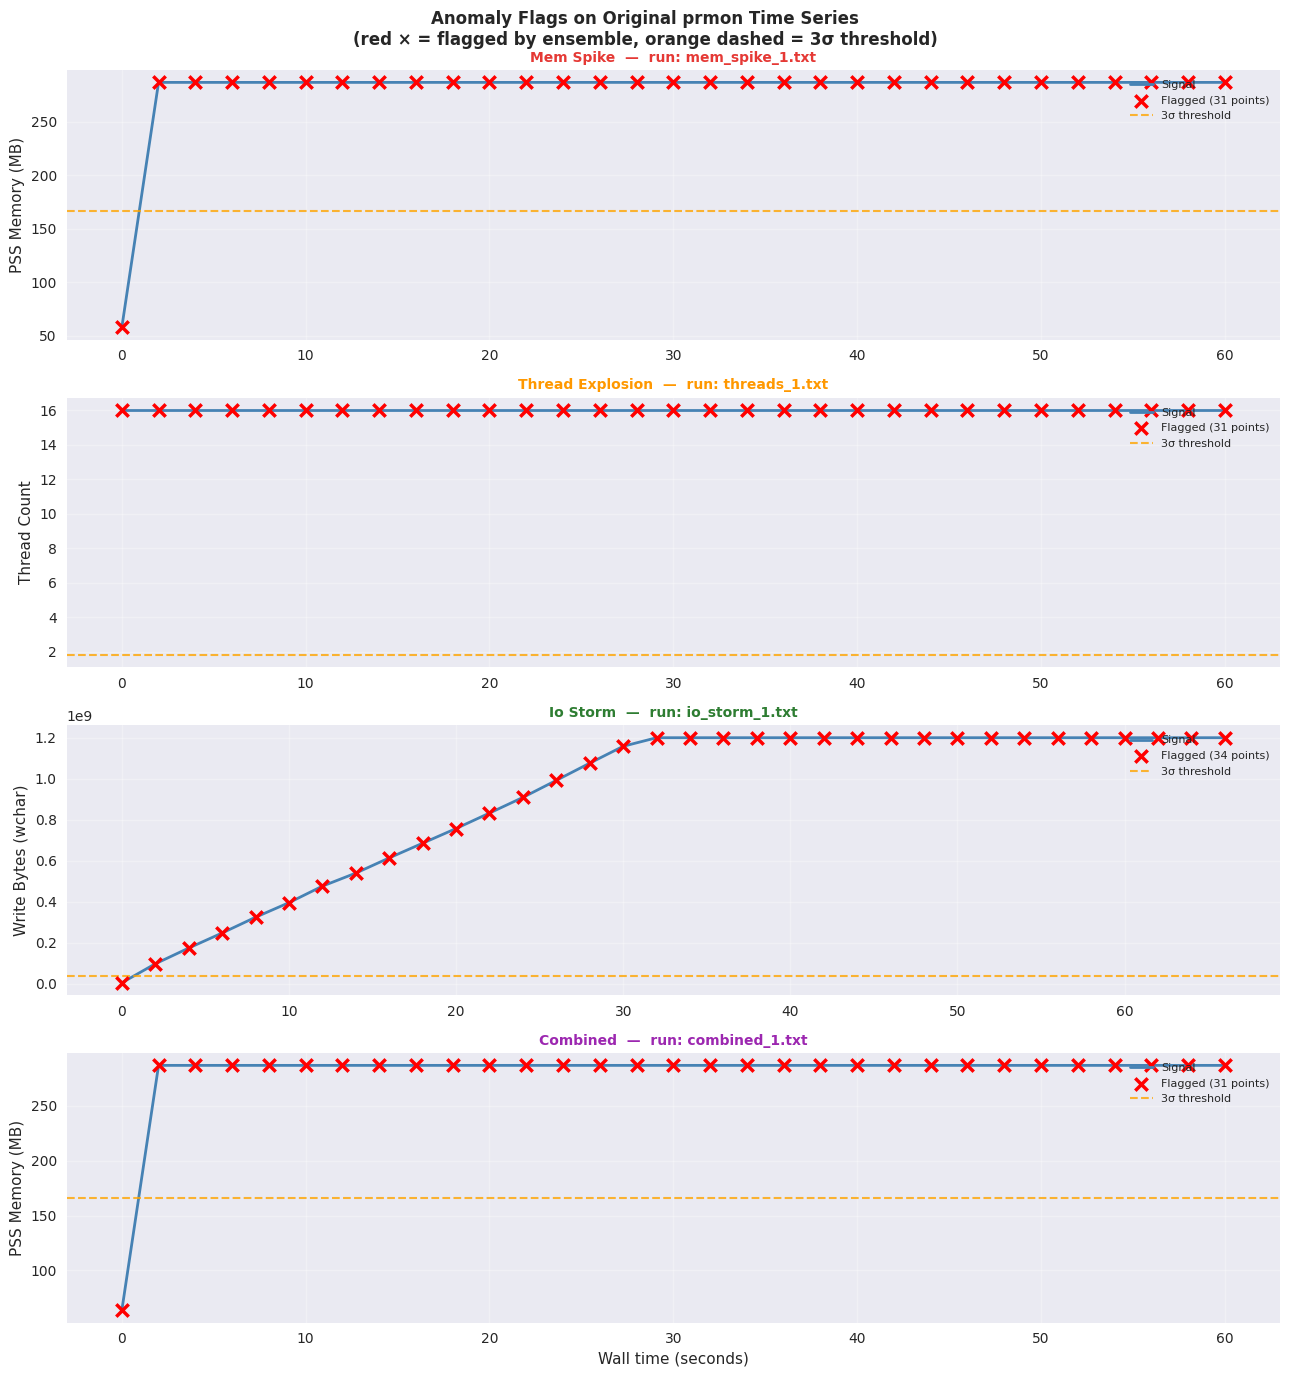

In [32]:
fig, axes = plt.subplots(4, 1, figsize=(13, 14), sharex=False)
fig.suptitle('Anomaly Flags on Original prmon Time Series\n'
             '(red × = flagged by ensemble, orange dashed = 3σ threshold)',
             fontsize=12, fontweight='bold')

scenarios = [
    ('mem_spike',        'pss',      'PSS Memory (MB)',     '#E53935'),
    ('thread_explosion', 'nthreads', 'Thread Count',        '#FF9800'),
    ('io_storm',         'wchar',    'Write Bytes (wchar)', '#2E7D32'),
    ('combined',         'pss',      'PSS Memory (MB)',     '#9C27B0'),
]

for ax, (atype, feat, ylabel, color) in zip(axes, scenarios):
    rid = df[df['anomaly_type'] == atype]['run_id'].iloc[0]
    sub = df[df['run_id'] == rid].sort_values('wtime')

    ax.plot(sub['wtime'], sub[feat], color='steelblue',
            linewidth=2, label='Signal', zorder=2)

    flagged = sub[sub['ensemble_pred'] == 1]
    if len(flagged):
        ax.scatter(flagged['wtime'], flagged[feat], color='red',
                   s=80, zorder=3, marker='x', linewidths=2.5,
                   label=f'Flagged ({len(flagged)} points)')

    threshold = df_normal[feat].mean() + 3 * df_normal[feat].std()
    ax.axhline(threshold, color='orange', linestyle='--',
               linewidth=1.5, alpha=0.8, label='3σ threshold')

    ax.set_ylabel(ylabel)
    ax.set_title(f'{atype.replace("_"," ").title()}  —  run: {rid}',
                 color=color, fontweight='bold', fontsize=10)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Wall time (seconds)')
plt.tight_layout()
plt.savefig('../plots/timeseries_flags.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score

models = {
    'Z-Score':          ('zscore_pred', 'zscore_score'),
    'MAD Z-Score':      ('mad_pred',    'mad_score'),
    'Isolation Forest': ('iso_pred',    'iso_score'),
    'LOF':              ('lof_pred',    'lof_score'),
    'One-Class SVM':    ('svm_pred',    'svm_score'),
    'Ensemble':         ('ensemble_pred','ensemble_score'),
}

rows = []
for name, (pred_col, score_col) in models.items():
    rows.append({
        'Model':     name,
        'F1':        round(f1_score(y_true, df[pred_col], zero_division=0), 3),
        'Precision': round(precision_score(y_true, df[pred_col], zero_division=0), 3),
        'Recall':    round(recall_score(y_true, df[pred_col], zero_division=0), 3),
        'ROC-AUC':   round(roc_auc_score(y_true, df[score_col]), 3),
    })

pd.DataFrame(rows).set_index('Model')

,F1,Precision,Recall,ROC-AUC
Model,,,,
Z-Score,0.940,0.887,1.0,1.000
MAD Z-Score,0.709,0.549,1.0,0.939
Isolation Forest,0.765,0.620,1.0,0.920
LOF,0.924,0.859,1.0,0.971
One-Class SVM,0.754,0.605,1.0,1.000
Ensemble,0.837,0.719,1.0,0.981


In [36]:
import os
os.makedirs('../scripts', exist_ok=True)

# Then paste the full unique_analysis.py code into a cell and save it:
script_content = open('../scripts/unique_analysis.py', 'w')

In [55]:
import glob
import pandas as pd

def load_prmon(filepath, label, run_id, anomaly_type=None):
    df = pd.read_csv(filepath, sep='\s+') # variable whitespace
    df['label'] = label
    df['run_id'] = run_id
    df['anomaly_type'] = anomaly_type if anomaly_type else 'normal'
    return df


anomaly_types = [
    'mem_spike',
    'mem_subtle',
    'slow_leak',
    'io_storm',
    'io_subtle',
    'cpu_hog',
    'threads',
    'threads_subtle',
    'combined',
]

rows = []

# Normal runs — check if you have any normal_*.txt files
for i, f in enumerate(glob.glob('normal_*.txt')):
    rows.append(load_prmon(f, label=0, run_id=f'normal_{i}'))

# Anomalous runs
for atype in anomaly_types:
    for i, f in enumerate(glob.glob(f'{atype}_*.txt')):
        rows.append(load_prmon(f, label=1, run_id=f'{atype}_{i}', anomaly_type=atype))
df = pd.concat(rows, ignore_index=True)
df = df.sort_values(['run_id', 'wtime']).reset_index(drop=True)

print(f"Rows: {len(df)} | Runs: {df['run_id'].nunique()}")
print(f"Anomaly ratio: {df['label'].mean()*100:.1f}%")
print(f"\nAnomaly type breakdown:\n{df['anomaly_type'].value_counts()}")

df.to_csv('full_dataset_injected.csv', index=False)
print("\nSaved to full_dataset_injected.csv")




ValueError: No objects to concatenate

In [56]:
import os, glob

print("Current directory:", os.getcwd())
print("\nAll txt files found:")
for f in glob.glob('*.txt'):
    print(f)

Current directory: /home/chaim/Atlas_gsoc26/notebooks

All txt files found:


In [64]:
import os, glob

ANOMALOUS_DIR = '/home/chaim/Atlas_gsoc26/data/anomalous/'
BASELINE_DIR  = '/home/chaim/Atlas_gsoc26/data/baseline/'

anomaly_types = [
    'mem_spike', 'mem_subtle', 'slow_leak',
    'io_storm', 'io_subtle', 'cpu_hog',
    'threads', 'threads_subtle', 'combined',
]

rows = []

# Normal runs from baseline folder
for i, f in enumerate(glob.glob(os.path.join(BASELINE_DIR, '*.txt'))):
    rows.append(load_prmon(f, label=0, run_id=f'normal_{i}'))

# Anomalous runs from anomalous folder
for atype in anomaly_types:
    for i, f in enumerate(glob.glob(os.path.join(ANOMALOUS_DIR, f'{atype}_*.txt'))):
        rows.append(load_prmon(f, label=1, run_id=f'{atype}_{i}', anomaly_type=atype))

df = pd.concat(rows, ignore_index=True)
df = df.sort_values(['run_id', 'wtime']).reset_index(drop=True)

print(f"Rows: {len(df)} | Runs: {df['run_id'].nunique()}")
print(f"Anomaly ratio: {df['label'].mean()*100:.1f}%")
print(f"\nAnomaly type breakdown:\n{df['anomaly_type'].value_counts()}")

df.to_csv('/home/chaim/Atlas_gsoc26/data/full_dataset_injected.csv', index=False)

Rows: 5838 | Runs: 189
Anomaly ratio: 44.8%

Anomaly type breakdown:
anomaly_type
normal            3221
threads            638
mem_spike          315
io_storm           301
combined           258
slow_leak          258
mem_subtle         255
cpu_hog            244
threads_subtle     227
io_subtle          121
Name: count, dtype: int64


In [65]:
# all the imports needed for our ml and feature engineering 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.metrics import (f1_score, precision_score, recall_score,
                              roc_auc_score, roc_curve, confusion_matrix,
                              precision_recall_curve, average_precision_score)
from scipy.stats import median_abs_deviation
import warnings
warnings.filterwarnings('ignore')

In [66]:
# Load both datasets
df_real  = pd.read_csv('../data/full_dataset_injected.csv')
df_synth = pd.read_csv('../data/full_dataset_atlas.csv')

# added columns , to know which values are real and which are synthetic
df_real['source']  = 'real'
df_synth['source'] = 'synthetic' #stamp each row with it's origin 

# I combined the databases to have a larger dataset to train my models 
df_combined = pd.concat([df_real, df_synth], ignore_index=True)
df_combined = df_combined.sort_values(['run_id','wtime']).reset_index(drop=True)

print("=== REAL (prmon burner) ===")  # used  prmon burner to stimulate data , via commands , you can view them on the documentation
print(f"Rows: {len(df_real)} | Runs: {df_real['run_id'].nunique()}")
print(f"Anomaly ratio: {df_real['label'].mean()*100:.1f}%") # I wrote this , to know the anomaly ratio , to get to know the dataset more 

print("\n=== SYNTHETIC (using claude ai ) ===")
print(f"Rows: {len(df_synth)} | Runs: {df_synth['run_id'].nunique()}")
print(f"Anomaly ratio: {df_synth['label'].mean()*100:.1f}%")

print("\n=== COMBINED ===")
print(f"Rows: {len(df_combined)} | Runs: {df_combined['run_id'].nunique()}")
print(f"Anomaly ratio: {df_combined['label'].mean()*100:.1f}%")

=== REAL (prmon burner) ===
Rows: 5838 | Runs: 189
Anomaly ratio: 44.8%

=== SYNTHETIC (using claude ai ) ===
Rows: 17372 | Runs: 216
Anomaly ratio: 53.1%

=== COMBINED ===
Rows: 23210 | Runs: 405
Anomaly ratio: 51.0%


In [67]:
def run_pipeline(df, dataset_name):
    df = df.sort_values(['run_id','wtime']).reset_index(drop=True)
    base_features = ['pss','vmem','rss','nthreads','wchar','rchar','nprocs','utime'] # feature engineering 
    
    for feat in ['pss','nthreads','wchar','utime']:
        df[f'{feat}_roll_mean'] = df.groupby('run_id')[feat].transform(
            lambda x: x.rolling(5, min_periods=1).mean()) # 5 timesteps per run to smooth teh noises and capture trends rather than focusing on a single noisy spike  
        df[f'{feat}_roll_std'] = df.groupby('run_id')[feat].transform(
            lambda x: x.rolling(5, min_periods=1).std().fillna(0)) # measures volatility in a short window 
        df[f'{feat}_roc'] = df.groupby('run_id')[feat].transform(
            lambda x: x.diff().fillna(0)) # rate of change
    
    # unsupervised anomaly detection 
    df_normal     = df[df['label'] == 0]
    contamination = min(float(df['label'].mean()), 0.5)
    y_true        = df['label'].values
    
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(df_normal[base_features].fillna(0))
    X_all   = scaler.transform(df[base_features].fillna(0))
    
    # Models
    models = {}
    
    # Z-Score
    z = pd.DataFrame({f: (df[f] - df_normal[f].mean()) /
                         (df_normal[f].std() + 1e-9) for f in base_features})
    df['zscore_pred']  = (z.abs() > 3.0).any(axis=1).astype(int)
    df['zscore_score'] = z.abs().max(axis=1)
    
    # MAD
    m = pd.DataFrame({f: 0.6745*(df[f] - np.median(df_normal[f])) /
                         (median_abs_deviation(df_normal[f]) + 1e-9)
                      for f in base_features})
    df['mad_pred']  = (m.abs() > 3.5).any(axis=1).astype(int)
    df['mad_score'] = m.abs().max(axis=1)
    
    # Isolation Forest
    iso = IsolationForest(n_estimators=200, contamination=contamination, random_state=42)
    iso.fit(X_train)
    df['iso_pred']  = (iso.predict(X_all) == -1).astype(int)
    df['iso_score'] = -iso.decision_function(X_all)
    
    # LOF
    lof = LocalOutlierFactor(n_neighbors=20, contamination=contamination, novelty=True)
    lof.fit(X_train)
    df['lof_pred']  = (lof.predict(X_all) == -1).astype(int)
    df['lof_score'] = -lof.decision_function(X_all)
    
    # One-Class SVM
    svm = OneClassSVM(kernel='rbf', gamma='auto', nu=contamination)
    svm.fit(X_train)
    df['svm_pred']  = (svm.predict(X_all) == -1).astype(int)
    df['svm_score'] = -svm.decision_function(X_all)
    
    # Ensemble
    votes = df[['zscore_pred','mad_pred','iso_pred','lof_pred','svm_pred']].sum(axis=1)
    df['ensemble_pred']  = (votes >= 3).astype(int)
    score_cols = ['zscore_score','mad_score','iso_score','lof_score','svm_score']
    normed = df[score_cols].apply(lambda c: (c-c.min())/(c.max()-c.min()+1e-9))
    df['ensemble_score'] = normed.mean(axis=1)
    
    # Evaluate
    model_cols = {
        'Z-Score':          ('zscore_pred', 'zscore_score'),
        'MAD Z-Score':      ('mad_pred',    'mad_score'),
        'Isolation Forest': ('iso_pred',    'iso_score'),
        'LOF':              ('lof_pred',    'lof_score'),
        'One-Class SVM':    ('svm_pred',    'svm_score'),
        'Ensemble':         ('ensemble_pred','ensemble_score'),
    }
    
    rows = []
    for name, (pred_col, score_col) in model_cols.items():
        rows.append({
            'Model':     name,
            'F1':        round(f1_score(y_true, df[pred_col], zero_division=0), 3),
            'Precision': round(precision_score(y_true, df[pred_col], zero_division=0), 3),
            'Recall':    round(recall_score(y_true, df[pred_col], zero_division=0), 3),
            'ROC-AUC':   round(roc_auc_score(y_true, df[score_col]), 3),
        })
    
    results = pd.DataFrame(rows).set_index('Model')
    results['Dataset'] = dataset_name
    print(f"\n=== {dataset_name} ===")
    print(results.drop(columns='Dataset'))
    return df, results

In [68]:
df_real_out,     results_real     = run_pipeline(df_real.copy(),     'Real prmon')
df_synth_out,    results_synth    = run_pipeline(df_synth.copy(),    'Synthetic')
df_combined_out, results_combined = run_pipeline(df_combined.copy(), 'Combined')


=== Real prmon ===
                     F1  Precision  Recall  ROC-AUC
Model                                              
Z-Score           0.851      0.903   0.804    0.962
MAD Z-Score       0.824      0.700   1.000    0.779
Isolation Forest  0.784      0.644   1.000    0.875
LOF               0.890      0.802   1.000    0.979
One-Class SVM     0.786      0.647   1.000    0.986
Ensemble          0.849      0.738   1.000    0.964

=== Synthetic ===
                     F1  Precision  Recall  ROC-AUC
Model                                              
Z-Score           0.830      0.942   0.742    0.850
MAD Z-Score       0.705      0.682   0.730    0.751
Isolation Forest  0.767      0.670   0.897    0.760
LOF               0.810      0.699   0.963    0.960
One-Class SVM     0.746      0.660   0.859    0.853
Ensemble          0.759      0.694   0.838    0.846

=== Combined ===
                     F1  Precision  Recall  ROC-AUC
Model                                              
Z-Score

In [76]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

def run_supervised_pipeline(df, dataset_name):
    df = df.sort_values(['run_id', 'wtime']).reset_index(drop=True)

    base_features = ['pss','vmem','rss','nthreads','wchar','rchar','nprocs','utime']
    
    # Same feature engineering as unsupervised pipeline
    for feat in ['pss','nthreads','wchar','utime']:
        df[f'{feat}_roll_mean'] = df.groupby('run_id')[feat].transform(
            lambda x: x.rolling(5, min_periods=1).mean())
        df[f'{feat}_roll_std'] = df.groupby('run_id')[feat].transform(
            lambda x: x.rolling(5, min_periods=1).std().fillna(0))
        df[f'{feat}_roc'] = df.groupby('run_id')[feat].transform(
            lambda x: x.diff().fillna(0))

    all_features = base_features + \
                   [f'{f}_{s}' for f in ['pss','nthreads','wchar','utime'] 
                    for s in ['roll_mean','roll_std','roc']]

    X = df[all_features].fillna(0)
    y = df['label'].values

    from sklearn.model_selection import GroupShuffleSplit
    
    # Split by run_id so entire runs are either in train or test
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    groups = df['run_id']
    
    train_idx, test_idx = next(gss.split(X, y, groups=groups))
    
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    models = {
        'Random Forest': RandomForestClassifier(
            n_estimators=200, class_weight='balanced', random_state=42),
        'Gradient Boosting': GradientBoostingClassifier(
            n_estimators=200, random_state=42),
        'XGBoost': XGBClassifier(
            n_estimators=200, scale_pos_weight=(y==0).sum()/(y==1).sum(),
            random_state=42, verbosity=0),
    }

    rows = []
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred  = model.predict(X_test)
        y_score = model.predict_proba(X_test)[:, 1]
        rows.append({
            'Model':     name,
            'F1':        round(f1_score(y_test, y_pred, zero_division=0), 3),
            'Precision': round(precision_score(y_test, y_pred, zero_division=0), 3),
            'Recall':    round(recall_score(y_test, y_pred, zero_division=0), 3),
            'ROC-AUC':   round(roc_auc_score(y_test, y_score), 3),
        })

    results = pd.DataFrame(rows).set_index('Model')
    print(f"\n=== {dataset_name} — Supervised ===")
    print(results)
    return results

In [77]:
sup_real     = run_supervised_pipeline(df_real.copy(),     'Real prmon')
sup_synth    = run_supervised_pipeline(df_synth.copy(),    'Synthetic')
sup_combined = run_supervised_pipeline(df_combined.copy(), 'Combined')


=== Real prmon — Supervised ===
                    F1  Precision  Recall  ROC-AUC
Model                                             
Random Forest      1.0        1.0     1.0      1.0
Gradient Boosting  1.0        1.0     1.0      1.0
XGBoost            1.0        1.0     1.0      1.0

=== Synthetic — Supervised ===
                    F1  Precision  Recall  ROC-AUC
Model                                             
Random Forest      1.0        1.0     1.0      1.0
Gradient Boosting  1.0        1.0     1.0      1.0
XGBoost            1.0        1.0     1.0      1.0

=== Combined — Supervised ===
                      F1  Precision  Recall  ROC-AUC
Model                                               
Random Forest      0.999        1.0   0.998      1.0
Gradient Boosting  1.000        1.0   1.000      1.0
XGBoost            1.000        1.0   1.000      1.0


In [73]:
from sklearn.model_selection import GroupShuffleSplit

# Split by run_id so entire runs are either in train or test
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
groups = df['run_id']

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

NameError: name 'X' is not defined

In [105]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

def run_autoencoder_pipeline(df, dataset_name):
    df = df.sort_values(['run_id', 'wtime']).reset_index(drop=True)

    base_features = ['pss','vmem','rss','nthreads','wchar','rchar','nprocs','utime']

    # Same feature engineering as your existing pipeline
    for feat in ['pss','nthreads','wchar','utime']:
        df[f'{feat}_roll_mean'] = df.groupby('run_id')[feat].transform(
            lambda x: x.rolling(5, min_periods=1).mean())
        df[f'{feat}_roll_std'] = df.groupby('run_id')[feat].transform(
            lambda x: x.rolling(5, min_periods=1).std().fillna(0))
        df[f'{feat}_roc'] = df.groupby('run_id')[feat].transform(
            lambda x: x.diff().fillna(0))

    all_features = base_features + \
                   [f'{f}_{s}' for f in ['pss','nthreads','wchar','utime']
                    for s in ['roll_mean','roll_std','roc']]

    scaler   = StandardScaler()
    df_normal = df[df['label'] == 0]

    # Fit scaler on normal data only — same as unsupervised pipeline
    X_normal = scaler.fit_transform(df_normal[all_features].fillna(0))
    X_all    = scaler.transform(df[all_features].fillna(0))
    y_true   = df['label'].values

    # --- Autoencoder Architecture ---
    input_dim = X_all.shape[1]  # 20 features

    class Autoencoder(nn.Module):
        def __init__(self, input_dim):
            super().__init__()
            self.encoder = nn.Sequential(
                nn.Linear(input_dim, 16),
                nn.ReLU(),
                nn.Linear(16, 8),
                nn.ReLU(),
                nn.Linear(8, 4),   # bottleneck
            )
            self.decoder = nn.Sequential(
                nn.Linear(4, 8),
                nn.ReLU(),
                nn.Linear(8, 16),
                nn.ReLU(),
                nn.Linear(16, input_dim),
            )

        def forward(self, x):
            return self.decoder(self.encoder(x))

    # --- Training ---
    X_tensor = torch.tensor(X_normal, dtype=torch.float32)
    loader   = DataLoader(TensorDataset(X_tensor), batch_size=64, shuffle=True)

    model     = Autoencoder(input_dim)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    model.train()
    for epoch in range(50):
        total_loss = 0
        for (batch,) in loader:
            optimizer.zero_grad()
            loss = criterion(model(batch), batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1}/50 — Loss: {total_loss/len(loader):.6f}")

    # --- Scoring ---
    model.eval()
    with torch.no_grad():
        X_all_tensor = torch.tensor(X_all, dtype=torch.float32)
        reconstructed = model(X_all_tensor).numpy()

    # Reconstruction error per row = anomaly score
    recon_errors = np.mean((X_all - reconstructed) ** 2, axis=1)

    # Threshold = 95th percentile of normal data reconstruction error
    normal_errors = recon_errors[y_true == 0]
    threshold     = np.percentile(normal_errors, 95)

    ae_pred = (recon_errors > threshold).astype(int)

    results = pd.DataFrame([{
        'Model':     'Autoencoder',
        'F1':        round(f1_score(y_true, ae_pred, zero_division=0), 3),
        'Precision': round(precision_score(y_true, ae_pred, zero_division=0), 3),
        'Recall':    round(recall_score(y_true, ae_pred, zero_division=0), 3),
        'ROC-AUC':   round(roc_auc_score(y_true, recon_errors), 3),
    }]).set_index('Model')

    print(f"\n=== {dataset_name} — Autoencoder ===")
    print(results)
    return df, results, recon_errors, threshold

In [106]:
_, ae_real,     re_real,     thr_real     = run_autoencoder_pipeline(df_real.copy(),     'Real prmon')
_, ae_synth,    re_synth,    thr_synth    = run_autoencoder_pipeline(df_synth.copy(),    'Synthetic')
_, ae_combined, re_combined, thr_combined = run_autoencoder_pipeline(df_combined.copy(), 'Combined')

  Epoch 10/50 — Loss: 0.171128
  Epoch 20/50 — Loss: 0.072926
  Epoch 30/50 — Loss: 0.049771
  Epoch 40/50 — Loss: 0.030159
  Epoch 50/50 — Loss: 0.019485

=== Real prmon — Autoencoder ===
                F1  Precision  Recall  ROC-AUC
Model                                         
Autoencoder  0.963      0.941   0.986    0.996
  Epoch 10/50 — Loss: 0.169789
  Epoch 20/50 — Loss: 0.139027
  Epoch 30/50 — Loss: 0.123524
  Epoch 40/50 — Loss: 0.105561
  Epoch 50/50 — Loss: 0.099964

=== Synthetic — Autoencoder ===
                F1  Precision  Recall  ROC-AUC
Model                                         
Autoencoder  0.858      0.947   0.785    0.889
  Epoch 10/50 — Loss: 0.104234
  Epoch 20/50 — Loss: 0.090289
  Epoch 30/50 — Loss: 0.078810
  Epoch 40/50 — Loss: 0.055380
  Epoch 50/50 — Loss: 0.043472

=== Combined — Autoencoder ===
                F1  Precision  Recall  ROC-AUC
Model                                         
Autoencoder  0.673      0.917   0.531    0.812


In [108]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, roc_auc_score
import pandas as pd
import numpy as np

# ── Load data ──────────────────────────────────────────────────────
df = pd.read_csv('../data/full_dataset_injected.csv')
df = df.sort_values(['run_id', 'wtime']).reset_index(drop=True)

# ── Engineer features ──────────────────────────────────────────────
for feat in ['pss', 'nthreads', 'wchar', 'utime']:
    df[f'{feat}_roll_mean'] = df.groupby('run_id')[feat].transform(
        lambda x: x.rolling(5, min_periods=1).mean())
    df[f'{feat}_roll_std'] = df.groupby('run_id')[feat].transform(
        lambda x: x.rolling(5, min_periods=1).std().fillna(0))
    df[f'{feat}_roc'] = df.groupby('run_id')[feat].transform(
        lambda x: x.diff().fillna(0))

BASE_FEATURES = ['pss', 'vmem', 'rss', 'nthreads', 'wchar', 'rchar', 'nprocs', 'utime']
ENG_FEATURES  = BASE_FEATURES + [
    f'{f}_{s}' for f in ['pss','nthreads','wchar','utime']
               for s in ['roll_mean','roll_std','roc']
]

# ── Run comparison ─────────────────────────────────────────────────
df_normal     = df[df['label'] == 0]
contamination = min(df['label'].mean(), 0.499)
y_true        = df['label'].values

results = []

for feat_set, label in [(BASE_FEATURES, 'Base (8)'), (ENG_FEATURES, 'Engineered (20)')]:
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(df_normal[feat_set].fillna(0))
    X_all   = scaler.transform(df[feat_set].fillna(0))

    for ModelClass, name, kwargs in [
        (IsolationForest, 'Isolation Forest', {'n_estimators':200,'contamination':contamination,'random_state':42}),
        (LocalOutlierFactor, 'LOF',           {'n_neighbors':20,'contamination':contamination,'novelty':True}),
    ]:
        m = ModelClass(**kwargs)
        m.fit(X_train)
        preds  = (m.predict(X_all) == -1).astype(int)
        scores = -m.score_samples(X_all)
        results.append({
            'Model':    name,
            'Features': label,
            'F1':       round(f1_score(y_true, preds, zero_division=0), 3),
            'ROC-AUC':  round(roc_auc_score(y_true, scores), 3),
        })

# ── Print result ───────────────────────────────────────────────────
results_df = pd.DataFrame(results).set_index(['Model','Features'])
print(results_df)
print()
print("Delta (Engineered - Base):")
for model in ['Isolation Forest', 'LOF']:
    base = results_df.loc[(model, 'Base (8)')]
    eng  = results_df.loc[(model, 'Engineered (20)')]
    print(f"  {model}: F1 {eng['F1']-base['F1']:+.3f} | ROC-AUC {eng['ROC-AUC']-base['ROC-AUC']:+.3f}")

                                     F1  ROC-AUC
Model            Features                       
Isolation Forest Base (8)         0.784    0.875
LOF              Base (8)         0.890    0.979
Isolation Forest Engineered (20)  0.674    0.835
LOF              Engineered (20)  0.845    0.979

Delta (Engineered - Base):
  Isolation Forest: F1 -0.110 | ROC-AUC -0.040
  LOF: F1 -0.045 | ROC-AUC +0.000


In [111]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, roc_auc_score
import pandas as pd
import numpy as np

def run_pipeline(df, dataset_name):
    df = df.sort_values(['run_id','wtime']).reset_index(drop=True) # sort data by run and timestamps to keep the temporal order 
    base_features = ['pss','vmem','rss','nthreads','wchar','rchar','nprocs','utime'] # raw prmon metrics — no transformation needed
    
    # unsupervised anomaly detection 
    # learn from normal data to flag any deviation 
    df_normal     = df[df['label'] == 0]
    contamination = min(float(df['label'].mean()), 0.5)
    y_true        = df['label'].values
    
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(df_normal[base_features].fillna(0))
    X_all   = scaler.transform(df[base_features].fillna(0))

    # Z-Score( measure how far away a data point from the average)
    z = pd.DataFrame({f: (df[f] - df_normal[f].mean()) /(df_normal[f].std() + 1e-9) for f in base_features}) 
    df['zscore_pred']  = (z.abs() > 3.0).any(axis=1).astype(int) # flag a row as anormal if any single feature exceeded 3 standard deviations 
    df['zscore_score'] = z.abs().max(axis=1)
    
    # MAD(median)
    m = pd.DataFrame({f: 0.6745*(df[f] - np.median(df_normal[f])) /
                         (median_abs_deviation(df_normal[f]) + 1e-9)
                      for f in base_features})
    df['mad_pred']  = (m.abs() > 3.5).any(axis=1).astype(int) # flag a row as anormal if any single feature exceeded 3.5 standard deviations 
    df['mad_score'] = m.abs().max(axis=1)

    # to look at all features together 
    # Isolation Forest 
    iso = IsolationForest(n_estimators=200, contamination=contamination, random_state=42)
    iso.fit(X_train) # Train Isolation Forest on normal behavior (200 trees for stability)
    df['iso_pred']  = (iso.predict(X_all) == -1).astype(int) # -1 = anomaly, 1 = normal
    df['iso_score'] = -iso.decision_function(X_all)  # Flip sign so higher score = more anomalous
    
    # LOF(local outlier factor) detect anomalies by comparing each point's local density
    lof = LocalOutlierFactor(n_neighbors=20, contamination=contamination, novelty=True)
    lof.fit(X_train) # Train by comparing each point's density to its 20 nearest neighbors
    df['lof_pred']  = (lof.predict(X_all) == -1).astype(int)
    df['lof_score'] = -lof.decision_function(X_all)
    
    # One-Class SVM : draws a tight boundary around normal training data , anything outside that boundary would be considered as anomalous
    svm = OneClassSVM(kernel='rbf', gamma='auto', nu=contamination)
    svm.fit(X_train)
    df['svm_pred']  = (svm.predict(X_all) == -1).astype(int)
    df['svm_score'] = -svm.decision_function(X_all)
    
    # Ensemble
    # Count how many models flagged each point as anomalous
    votes = df[['zscore_pred','mad_pred','iso_pred','lof_pred','svm_pred']].sum(axis=1)
    df['ensemble_pred']  = (votes >= 3).astype(int)
    # Normalize each model's score to 0-1 scale so they're comparable
    score_cols = ['zscore_score','mad_score','iso_score','lof_score','svm_score']
    normed = df[score_cols].apply(lambda c: (c-c.min())/(c.max()-c.min()+1e-9))
    df['ensemble_score'] = normed.mean(axis=1)
    
    # Evaluate
    model_cols = {
        'Z-Score':          ('zscore_pred', 'zscore_score'),
        'MAD Z-Score':      ('mad_pred',    'mad_score'),
        'Isolation Forest': ('iso_pred',    'iso_score'),
        'LOF':              ('lof_pred',    'lof_score'),
        'One-Class SVM':    ('svm_pred',    'svm_score'),
        'Ensemble':         ('ensemble_pred','ensemble_score'),
    }
    
    rows = []
    for name, (pred_col, score_col) in model_cols.items():
        rows.append({
            'Model':     name,
            'F1':        round(f1_score(y_true, df[pred_col], zero_division=0), 3),
            'Precision': round(precision_score(y_true, df[pred_col], zero_division=0), 3),
            'Recall':    round(recall_score(y_true, df[pred_col], zero_division=0), 3),
            'ROC-AUC':   round(roc_auc_score(y_true, df[score_col]), 3),
        })
    # comparasion of all models 
    results = pd.DataFrame(rows).set_index('Model')
    results['Dataset'] = dataset_name
    print(f"\n=== {dataset_name} ===")
    print(results.drop(columns='Dataset'))
    return df, results

In [112]:
df_real_out,     results_real     = run_pipeline(df_real.copy(),     'Real prmon')
df_synth_out,    results_synth    = run_pipeline(df_synth.copy(),    'Synthetic')
df_combined_out, results_combined = run_pipeline(df_combined.copy(), 'Combined')


=== Real prmon ===
                     F1  Precision  Recall  ROC-AUC
Model                                              
Z-Score           0.851      0.903   0.804    0.962
MAD Z-Score       0.824      0.700   1.000    0.779
Isolation Forest  0.784      0.644   1.000    0.875
LOF               0.890      0.802   1.000    0.979
One-Class SVM     0.786      0.647   1.000    0.986
Ensemble          0.849      0.738   1.000    0.964

=== Synthetic ===
                     F1  Precision  Recall  ROC-AUC
Model                                              
Z-Score           0.830      0.942   0.742    0.850
MAD Z-Score       0.705      0.682   0.730    0.751
Isolation Forest  0.767      0.670   0.897    0.760
LOF               0.810      0.699   0.963    0.960
One-Class SVM     0.746      0.660   0.859    0.853
Ensemble          0.759      0.694   0.838    0.846

=== Combined ===
                     F1  Precision  Recall  ROC-AUC
Model                                              
Z-Score